# Unconstrained Backtest Example: TS Momentum in Cryptocurrencies

We will run a simple unconstrained backtest to assess whether 4 of the larger coins (BTC, ETH, ADA, BNB) show time-series momentum. In other words, if they have done well recently, do they tend to continue to do well? The flow of events will be as follow:

1. Compute returns for these coins (BTC, ETH, ADA, BNB) since 2016.
2. The signal on each day for each coin will be: 
$$
\frac{\sqrt{10} * (\bar{ret}_{10 days} - \bar{ret}_{365 days})}{\sigma_{365 days}}
$$
You can think of this as the z-score of the past 10 day returns, and it tells us if a coin is doing better than it usually does. Technical note: we multiply by $\sqrt{10}$ here because the stdev is calculated on daily data but we want to "z-score" the average 10 day returns.

3. The signal from (2) will have extreme values. Pass them through a $tanh$ function to curtail these. These are your final daily portfolio weights.
4. Compute the returns to the weights from (3). 
5. Compute the Sharpe for the given strategies and plot the cumulative returns for each cryptocurrency.
6. Understand how correlated are the timing strategies with the underlying assets.

In [1]:
import yfinance as yf 
import numpy as np
import matplotlib.pyplot as plt

### 1. Load & Prepare Cryptocurrency Price Data

We download **daily adjusted close prices** for four major cryptocurrencies:
- **BTC** (Bitcoin)
- **ETH** (Ethereum)
- **ADA** (Cardano)
- **BNB** (Binance Coin)

**Time period**: `2016-01-01` to present  
**Source**: Yahoo Finance (`yfinance`)  
**Returns**: Simple daily returns from **adjusted close**:
$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

In [2]:
data = yf.download(['ADA-USD','BNB-USD','BTC-USD','ETH-USD'],'2016-1-1')['Close']
# Compute the daily returns
rets = data / data.shift() - 1
# OR using pandas built-in function
rets = data.pct_change()
rets.tail()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_10886/2506750343.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(['ADA-USD','BNB-USD','BTC-USD','ETH-USD'],'2016-1-1')['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2026-02-06,0.128015,0.083883,0.125248,0.132682
2026-02-07,-0.014006,-0.015319,-0.018049,0.013164
2026-02-08,-0.007718,-0.010963,0.014185,-0.000855
2026-02-09,-0.002053,-0.006715,-0.002049,0.007088
2026-02-10,-0.025589,-0.028835,-0.030932,-0.050627


### 2. Construct the Time-Series Momentum Signal

For each coin and each day \( t \), the momentum signal is defined as:

$$
S_t = 
\
\sqrt{10} \times 
\frac{
\bar{R}_{t,10} - \bar{R}_{t,365}} {\sigma_{R_{t,365}}}
$$

Where:
- $\bar{R}_{t,10}$: **Mean of the past 10 daily returns** (excluding today)
- $\bar{R}_{t,365}$: **Mean of the past 365 daily returns**
- $\sigma_{t,365}$: **Standard deviation of daily returns over the past 365 days**

---

Why $\sqrt{10}$? We compare:
- A **10-day cumulative return** ≈ $\sqrt{10} \times$ daily return
- To a **daily volatility** estimate

To make the ratio **scale-consistent** (i.e., a true *z-score*), we **scale the numerator** by $\sqrt{10}$:

$$
\frac{10 \times \bar{R}_{t,10}}{\sigma_{t,365}}
\quad \text{vs.} \quad
\frac{\text{10-day total return}}{\text{10-day vol}} \approx \frac{10 \times \bar{r}}{\sqrt{10} \times \sigma} \propto \sqrt{10} \times \bar{r}/\sigma
$$

In [3]:
# Compute portfolios and strategy returns
# --- 1. Raw momentum signal ---
port = (np.sqrt(10)*(rets.rolling(10,min_periods=1).mean() - rets.rolling(365,min_periods=10).mean())) / rets.rolling(365,min_periods=10).std()

# --- 2. Apply tanh to bound positions in [-1, 1] ---
port = np.tanh(port)

# --- 3. Strategy returns: use YESTERDAY's signal (no lookahead) ---
strat_ret = port.shift()*rets
print("Strategy Sharpe Ratio:", strat_ret.mean()/strat_ret.std()*np.sqrt(365))
print("Strategy Returns ")
strat_ret.tail()

Strategy Sharpe Ratio: Ticker
ADA-USD    0.617964
BNB-USD    0.802301
BTC-USD    0.607325
ETH-USD    0.727597
dtype: float64
Strategy Returns 


Ticker,ADA-USD,BNB-USD,BTC-USD,ETH-USD
Date,,,,
2026-02-06,-0.120825,-0.083825,-0.125204,-0.132436
2026-02-07,0.011776,0.015276,0.017881,-0.013047
2026-02-08,0.006569,0.010942,-0.014104,0.000845
2026-02-09,0.001513,0.006692,0.001983,-0.006875
2026-02-10,0.016070,0.028725,0.029864,0.047477


We can now plot the strategy cumulative returns

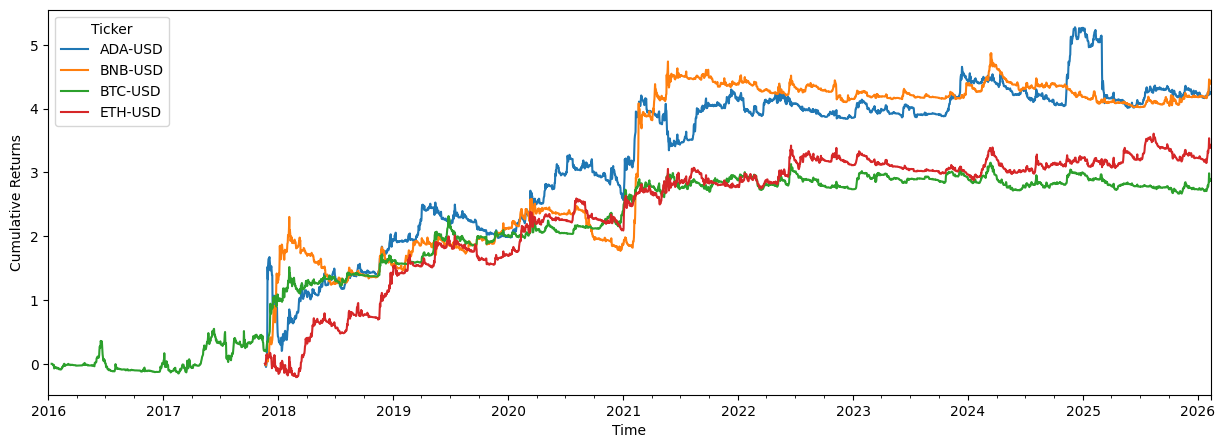

In [4]:
# plot strategy cum returns
strat_ret.cumsum().plot()
plt.xlabel('Time')
plt.ylabel('Cumulative Returns')
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()


Following that, we can print the strategy's correlation with the underlying assets

In [5]:
strat_ret.corrwith(rets)

Ticker
ADA-USD    0.065745
BNB-USD    0.141808
BTC-USD   -0.132047
ETH-USD   -0.158765
dtype: float64

As we can see from the above, they are fairly lowly correlated, suggesting we could enhance a buy and hold strategy with TS momentum